In [1]:
#Import required modules
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import oggm.cfg as cfg
from oggm import utils, workflow, tasks, DEFAULT_BASE_URL
from oggm.shop import gcm_climate

In [2]:
# Initialize OGGM and set up the default run parameters
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir('OGGM_gcm_run', reset=True)

# Enable storing model geometry for run_with_hydro
cfg.PARAMS['store_model_geometry'] = True 

# Define Vestari Hagafellsjökull 
rgi_ids = ['RGI60-06.00291']

# Get the pre-processed glacier directories
gdirs = workflow.init_glacier_directories(rgi_ids, from_prepro_level=5, prepro_base_url=DEFAULT_BASE_URL)

2025-03-10 21:28:36: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-03-10 21:28:36: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-03-10 21:28:36: oggm.cfg: Multiprocessing: using slurm allocated processors (N=4)
2025-03-10 21:28:37: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2025-03-10 21:28:37: oggm.workflow: init_glacier_directories from prepro level 5 on 1 glaciers.
2025-03-10 21:28:37: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


In [3]:

# Define the 5 GCMs and SSP scenarios 
gcms = [
    'gfdl-esm4_r1i1p1f1', 
    'mpi-esm1-2-hr_r1i1p1f1', 
    'mri-esm2-0_r1i1p1f1', 
    'ipsl-cm6a-lr_r1i1p1f1', 
    'ukesm1-0-ll_r1i1p1f2'
]
scenarios = ['ssp126', 'ssp370', 'ssp585']


In [4]:
# Download and process GCM data
for gcm in gcms:
    for ssp in scenarios:
        workflow.execute_entity_task(
            gcm_climate.process_monthly_isimip_data,
            gdirs, 
            ssp=ssp,
            member=gcm,
            output_filesuffix=f'_ISIMIP3b_{gcm}_{ssp}'
        )

# Perform a spinup based on historical data
ds_spinup = utils.compile_run_output(gdirs, input_filesuffix='_spinup_historical')

# Run projections with hydrological outputs
for gcm in gcms:
    for ssp in scenarios:
        rid = f'_ISIMIP3b_{gcm}_{ssp}'
        workflow.execute_entity_task(
            tasks.run_with_hydro, gdirs,
            run_task=tasks.run_from_climate_data,
            climate_filename='gcm_data',
            climate_input_filesuffix=rid,
            init_model_filesuffix='_spinup_historical',
            output_filesuffix=f'{rid}_hydro',
            store_monthly_hydro=True
        )


2025-03-10 21:28:41: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-03-10 21:28:43: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-03-10 21:28:44: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-03-10 21:28:45: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-03-10 21:28:47: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-03-10 21:28:48: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-03-10 21:28:49: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-03-10 21:28:50: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-03-10 21:28:51: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-03-10 21:28:52: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1

In [7]:
# Compile results for each GCM and SSP scenario
results = []
for gcm in gcms:
    for ssp in scenarios:
        rid = f'_ISIMIP3b_{gcm}_{ssp}_hydro'
        with xr.open_dataset(gdirs[0].get_filepath('model_diagnostics', filesuffix=rid)) as ds:
            ds = ds.isel(time=slice(0, -1)).load()
            ds = ds.assign_coords(GCM=gcm, SCENARIO=ssp)
            results.append(ds)

# Combine all results into a single dataset
ds_total = xr.concat(results, dim='run')

# Select the variables relevant for runoff
runoff_vars = ['melt_on_glacier']
# Convert volume  Gigatonnes instead of kg
ds_total_runoff = ds_total[runoff_vars].clip(0) * 1e-9
# Sum the runoff variables along the time and run dimensions
ds_total_runoff = ds_total_runoff.to_array(dim='vars').sum(dim='vars')

# Calculate mean and standard deviation for each scenario
runoff_mean = ds_total_runoff.groupby('SCENARIO').mean(dim='run')
runoff_std = ds_total_runoff.groupby('SCENARIO').std(dim='run')

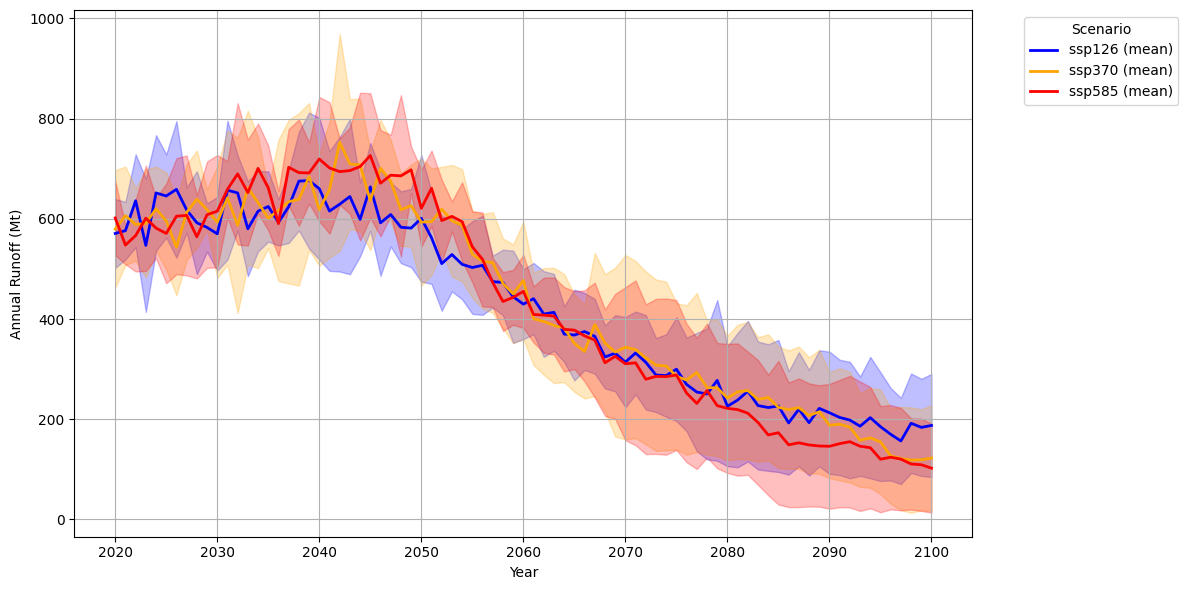

In [8]:
# Color dictionary for scenarios
color_dict = {'ssp126': 'blue', 'ssp370': 'orange', 'ssp585': 'red'}

# Plot meltwater runoff changes with improved colors
fig, ax = plt.subplots(figsize=(12, 6))
for scenario in color_dict.keys():
    # Plot mean meltwater runoff
    ax.plot(
        runoff_mean.time,
        runoff_mean.sel(SCENARIO=scenario),
        color=color_dict[scenario],
        label=f'{scenario} (mean)',
        lw=2
    )
    # Add shaded region with colors that blend better
    ax.fill_between(
        runoff_mean.time,
        runoff_mean.sel(SCENARIO=scenario) - runoff_std.sel(SCENARIO=scenario),
        runoff_mean.sel(SCENARIO=scenario) + runoff_std.sel(SCENARIO=scenario),
        color=color_dict[scenario],
        alpha=0.25  # Slightly lower alpha
    )

ax.set_ylabel('Annual Runoff (Mt)')
ax.set_xlabel('Year')
ax.grid(True)
ax.legend(title='Scenario', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Runoff_SSP.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:

# Cumulative runoff attributed to glacier melt
# Select the melt_on_glacier variable
melt_on_glacier = ds_total['melt_on_glacier'].clip(0) * 1e-12  # Convert kg to GT

# Calculate cumulative runoff for each run
cumulative_runoff = melt_on_glacier.cumsum(dim='time')

# Calculate mean and standard deviation for each scenario
cumulative_runoff_mean = cumulative_runoff.groupby('SCENARIO').mean(dim='run')
cumulative_runoff_std = cumulative_runoff.groupby('SCENARIO').std(dim='run')


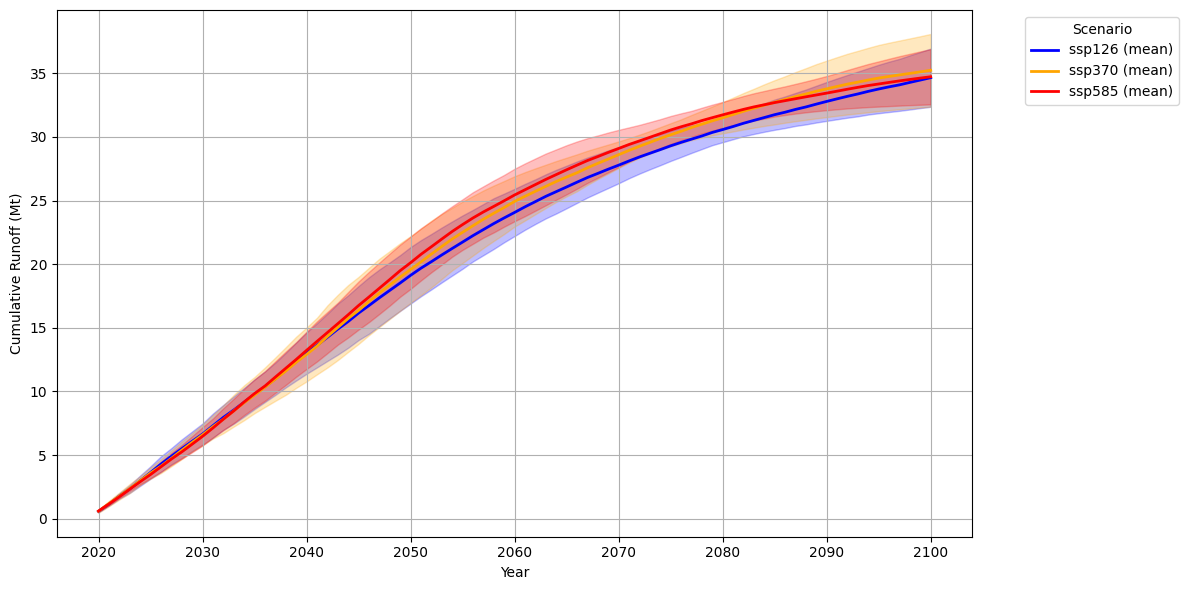

In [17]:
# Plot cumulative runoff attributed to glacier melt
fig2, ax2 = plt.subplots(figsize=(12, 6))
for scenario in color_dict.keys():
    # Plot mean cumulative runoff
    ax2.plot(
        cumulative_runoff_mean.time,
        cumulative_runoff_mean.sel(SCENARIO=scenario),
        color=color_dict[scenario],
        label=f'{scenario} (mean)',
        lw=2
    )
    # Add shaded region
    ax2.fill_between(
        cumulative_runoff_mean.time,
        cumulative_runoff_mean.sel(SCENARIO=scenario) - cumulative_runoff_std.sel(SCENARIO=scenario),
        cumulative_runoff_mean.sel(SCENARIO=scenario) + cumulative_runoff_std.sel(SCENARIO=scenario),
        color=color_dict[scenario],
        alpha=0.25  # Slightly lower alpha
    )

ax2.set_ylabel('Cumulative Runoff (Mt)')
ax2.set_xlabel('Year')
ax2.grid(True)
ax2.legend(title='Scenario', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Cumulative_Runoff_SSP.png', dpi=300, bbox_inches='tight')
plt.show()